In [2]:
import nltk
import pandas as pd
from pathlib import Path

from sklearn.datasets import fetch_20newsgroups

data_dir = Path("20_newsgroups")

texts = []
targets = []

"""for file_path in data_dir.rglob("*"):
    if file_path.is_file():
        texts.append(file_path.read_text(encoding="utf-8", errors="ignore"))
        targets.append(file_path.parent.name)

news = pd.DataFrame({"text": texts, "target": targets})
"""
news = fetch_20newsgroups(
    subset='train', 
    categories=[
           'sci.med',
    'rec.sport.hockey',
    'comp.graphics',
    'talk.politics.guns'
        ], 
    remove=('headers', 'footers', 'quotes'))

news = pd.DataFrame({
        "text": news["data"],
        "target": [news["target_names"][t] for t in news["target"]]
    })

print(news.head())

                                                text              target
0  \n\n\nThere's a lot of evidence, it just hasn'...             sci.med
1  : Currently, I use a shareware program called ...       comp.graphics
2  \nThere is a (likely) veto proof majority in t...  talk.politics.guns
3  \nI have already called senators, legislators ...  talk.politics.guns
4  \n\nYup, you said it.  I admire such honesty. ...  talk.politics.guns


In [3]:
news = pd.read_csv("bbc-news-data.csv", sep=None, engine="python")
news['category'] = news['category'].astype('category')
print(news['category'].value_counts())


category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [4]:
#preprocessamento
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def preprocess_lemma(text):

    doc = nlp(text)

    return [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop      # remove stopwords
        and not token.is_punct    # remove pontuação
        and not token.is_space    # remove espaços
        and token.is_alpha        # mantém apenas palavras   
        and len(token) > 2       # remove palavras muito curtas   
    ]
news["content"] = news["content"].apply(preprocess_lemma)

In [5]:
news["content"].head()

0    [quarterly, profit, media, giant, timewarner, ...
1    [dollar, hit, high, level, euro, month, federa...
2    [owner, embattle, russian, oil, giant, yukos, ...
3    [british, airways, blame, high, fuel, price, d...
4    [share, drink, food, firm, allied, domecq, ris...
Name: content, dtype: object

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

news["content_text"] = news["content"].apply(lambda x: " ".join(x))

X_tfidf = vectorizer.fit_transform(news["content_text"])

In [7]:
from sklearn.decomposition import PCA

X_2d = PCA(n_components=2).fit_transform(
    X_tfidf.toarray()
)

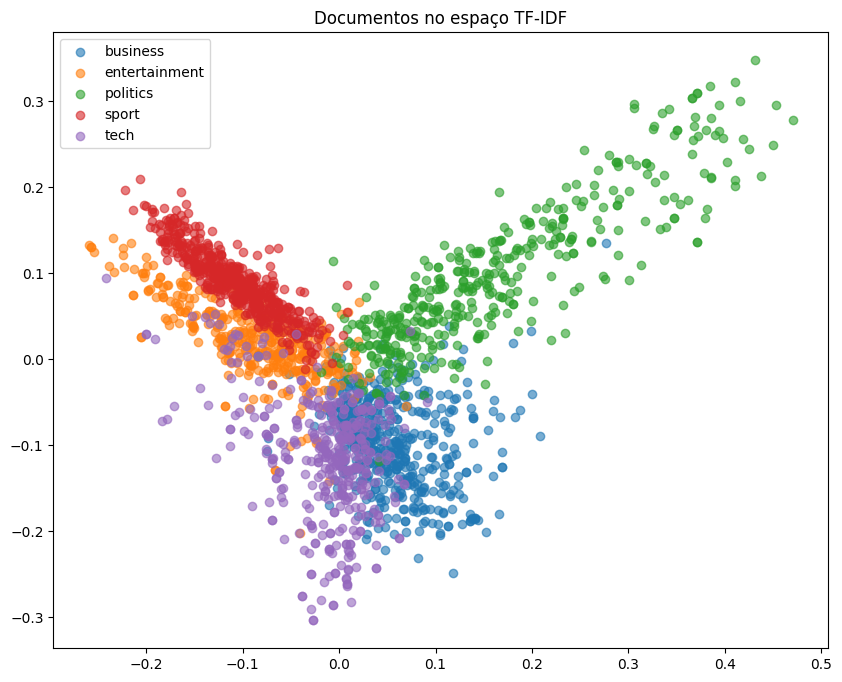

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for categoria in news["category"].unique():

    mask = news["category"] == categoria

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=categoria,
        alpha=0.6
    )

plt.legend()
plt.title("Documentos no espaço TF-IDF")
plt.show()

In [9]:
from rank_bm25 import BM25Okapi
import numpy as np

tokenized_docs = [
    doc.split()
    for doc in news["content_text"]
]

bm25 = BM25Okapi(tokenized_docs)

n = len(tokenized_docs)

bm25_matrix = np.zeros((n, n))

for i, doc in enumerate(tokenized_docs):
    bm25_matrix[i] = bm25.get_scores(doc)

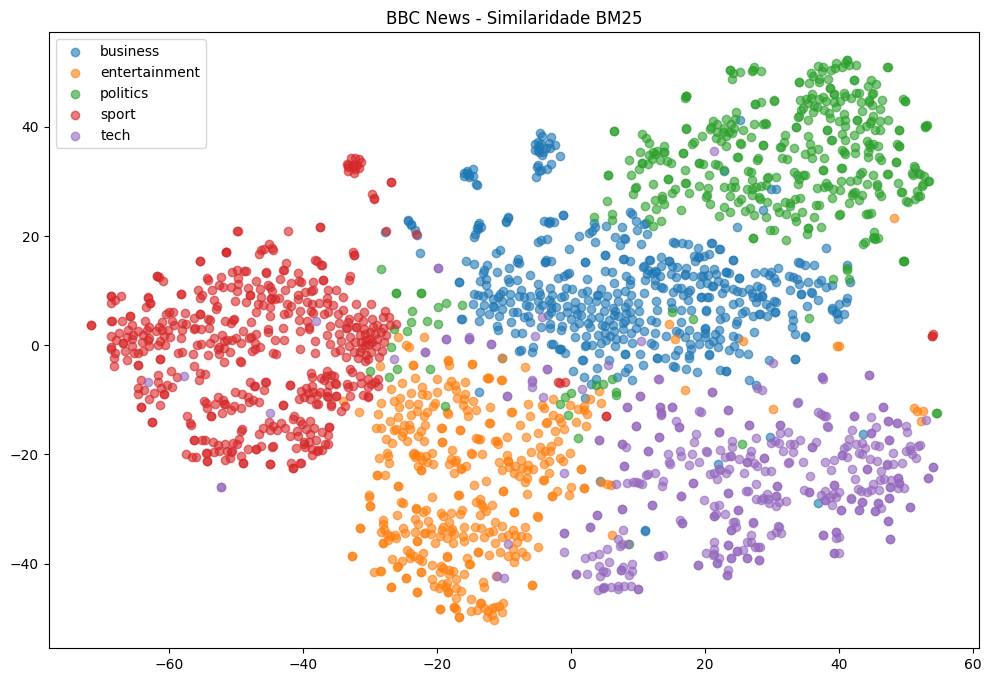

In [10]:
bm25_matrix.shape
from sklearn.manifold import TSNE

X_2d = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
).fit_transform(bm25_matrix)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for categoria in news["category"].unique():

    mask = news["category"] == categoria

    plt.scatter(
        X_2d[mask,0],
        X_2d[mask,1],
        label=categoria,
        alpha=0.6
    )

plt.legend()
plt.title("BBC News - Similaridade BM25")
plt.show()

In [32]:
# =====================================================
# Divisão treino/teste
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

train_news, test_news = train_test_split(
    news,
    test_size=0.2,
    stratify=news["category"],
    random_state=42
)

# =====================================================
# Preparação dos documentos
# Funciona tanto para listas de tokens quanto para texto
# =====================================================

def prepare_text(doc):
    if isinstance(doc, list):
        return " ".join(map(str, doc))
    return str(doc)

train_docs = train_news["content"].apply(prepare_text)
test_docs = test_news["content"].apply(prepare_text)

# =====================================================
# Vetorização TF-IDF
# =====================================================

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(train_docs)   # documentos
Y = vectorizer.transform(test_docs)        # consultas

# =====================================================
# Similaridade Cosseno
# =====================================================

similarity = cosine_similarity(X, Y)

print("Matriz de documentos:", X.shape)
print("Matriz de consultas :", Y.shape)
print("Matriz de similaridade:", similarity.shape)

Matriz de documentos: (1780, 20077)
Matriz de consultas : (445, 20077)
Matriz de similaridade: (1780, 445)


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(X, Y)

,P@10,P@20,P@50,P@100,MAP
Vetorial,0.890787,0.873708,0.837753,0.784022,0.598444


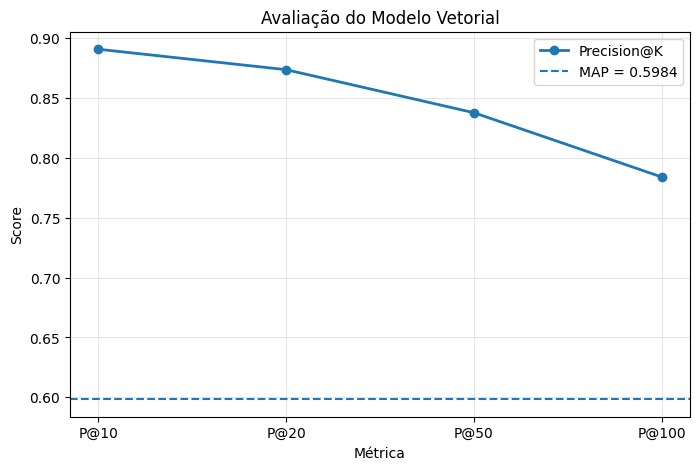


Resultados:
P@10: 0.8908
P@20: 0.8737
P@50: 0.8378
P@100: 0.7840
MAP: 0.5984


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Avaliação Vetorial (P@K + MAP)
# =====================================================

k_values = [10, 20, 50, 100]

p_at_k_acc = {k: [] for k in k_values}
ap_scores = []

for i in range(len(test_news)):

    # ranking dos documentos para a query i
    sim_scores = similarity[:, i]
    ranking_idx = np.argsort(sim_scores)[::-1]

    query_category = test_news.iloc[i]["category"]

    # -----------------------------
    # Precision@K
    # -----------------------------
    for k in k_values:

        topk = ranking_idx[:k]

        relevant = sum(
            train_news.iloc[idx]["category"] == query_category
            for idx in topk
        )

        p_at_k_acc[k].append(relevant / k)

    # -----------------------------
    # Average Precision (AP)
    # -----------------------------
    total_relevant = (
        train_news["category"] == query_category
    ).sum()

    relevant_found = 0
    precision_sum = 0

    for rank, idx in enumerate(ranking_idx, start=1):

        if train_news.iloc[idx]["category"] == query_category:
            relevant_found += 1
            precision_sum += relevant_found / rank

    ap = precision_sum / total_relevant if total_relevant > 0 else 0
    ap_scores.append(ap)

# =====================================================
# Resultados
# =====================================================

results = {
    f"P@{k}": np.mean(p_at_k_acc[k])
    for k in k_values
}

results["MAP"] = np.mean(ap_scores)

results_df = pd.DataFrame(
    results,
    index=["Vetorial"]
)

display(results_df)

# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(8, 5))

plt.plot(
    [f"P@{k}" for k in k_values],
    [results[f"P@{k}"] for k in k_values],
    marker="o",
    linewidth=2,
    label="Precision@K"
)

plt.axhline(
    y=results["MAP"],
    linestyle="--",
    label=f"MAP = {results['MAP']:.4f}"
)

plt.title("Avaliação do Modelo Vetorial")
plt.ylabel("Score")
plt.xlabel("Métrica")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

print("\nResultados:")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

,P@10,P@20,P@50,P@100,MAP
BM25,91.93,90.04,86.13,80.43,61.0


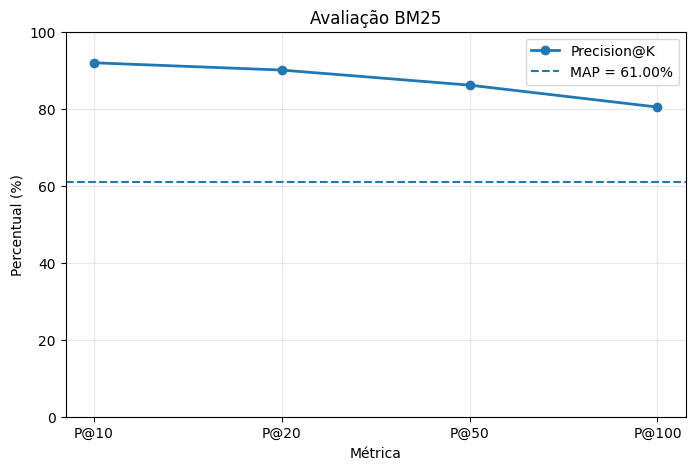


Resultados:
P@10: 91.93%
P@20: 90.04%
P@50: 86.13%
P@100: 80.43%
MAP: 61.00%


In [35]:
from rank_bm25 import BM25Okapi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Preparação dos documentos
# =====================================================

def prepare_tokens(doc):
    if isinstance(doc, list):
        return [str(t) for t in doc]
    return str(doc).split()

train_tokens = train_news["content"].apply(prepare_tokens).tolist()
test_tokens = test_news["content"].apply(prepare_tokens).tolist()

# =====================================================
# Índice BM25
# =====================================================

bm25 = BM25Okapi(train_tokens)

# =====================================================
# Avaliação
# =====================================================

k_values = [10, 20, 50, 100]

p_at_k_acc = {k: [] for k in k_values}
ap_scores = []

for i, query_tokens in enumerate(test_tokens):

    scores = bm25.get_scores(query_tokens)

    ranking_idx = np.argsort(scores)[::-1]

    query_category = test_news.iloc[i]["category"]

    # -----------------------------
    # Precision@K
    # -----------------------------
    for k in k_values:

        topk = ranking_idx[:k]

        relevant = sum(
            train_news.iloc[idx]["category"] == query_category
            for idx in topk
        )

        p_at_k_acc[k].append(relevant / k)

    # -----------------------------
    # Average Precision
    # -----------------------------
    total_relevant = (
        train_news["category"] == query_category
    ).sum()

    relevant_found = 0
    precision_sum = 0

    for rank, idx in enumerate(ranking_idx, start=1):

        if train_news.iloc[idx]["category"] == query_category:
            relevant_found += 1
            precision_sum += relevant_found / rank

    ap = precision_sum / total_relevant if total_relevant > 0 else 0
    ap_scores.append(ap)

# =====================================================
# Resultados (%)
# =====================================================

results = {
    f"P@{k}": np.mean(p_at_k_acc[k]) * 100
    for k in k_values
}

results["MAP"] = np.mean(ap_scores) * 100

results_df = pd.DataFrame(
    results,
    index=["BM25"]
)

display(results_df.round(2))

# =====================================================
# Gráfico
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    [f"P@{k}" for k in k_values],
    [results[f"P@{k}"] for k in k_values],
    marker="o",
    linewidth=2,
    label="Precision@K"
)

plt.axhline(
    y=results["MAP"],
    linestyle="--",
    label=f"MAP = {results['MAP']:.2f}%"
)

plt.title("Avaliação BM25")
plt.ylabel("Percentual (%)")
plt.xlabel("Métrica")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

print("\nResultados:")
for metric, value in results.items():
    print(f"{metric}: {value:.2f}%")

In [12]:
from nltk.corpus import stopwords
nltk.download("stopwords")

news['text'] = news['text'].str.replace(r'[^\w\s]+', '', regex=True)
news['text'] = news['text'].str.lower()

stopwords = nltk.corpus.stopwords.words('english')
newStopWords = ['path','newsgroups', 'srv', 'lines', 'subject', 'organization']
stopwords.extend(newStopWords)
news['text'] = news['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stopwords)]))


print(news.head())



[nltk_data] Downloading package stopwords to
[nltk_data]     /home/agnesmva/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


KeyError: 'text'

In [ ]:

#tokenization nad lemmanization

from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
news["text"] = news["text"].apply(word_tokenize)
lemmatizer = WordNetLemmatizer()
news["text"] = news["text"].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
#stemmer = nltk.PorterStemmer()
#news["text"] = news["text"].apply(lambda x: [stemmer.stem(word) for word in x])

print(news.head())


[nltk_data] Downloading package punkt to /home/agnesmva/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/agnesmva/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/agnesmva/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                                text              target
0  [there, lot, evidence, hasnt, adequately, gath...             sci.med
1  [currently, use, shareware, program, called, g...       comp.graphics
2  [likely, veto, proof, majority, house, senate,...  talk.politics.guns
3  [already, called, senator, legislator, governo...  talk.politics.guns
4  [yup, said, admire, honesty, fire, anschutz, 2...  talk.politics.guns


In [ ]:
#query preprocessing
"""data_dir = Path("mini_newsgroups")

texts = []
targets = []

all_files = sorted([p for p in data_dir.rglob("*") if p.is_file()])[:5]
for file_path in all_files:
    texts.append(file_path.read_text(encoding="utf-8", errors="ignore"))
    targets.append(file_path.parent.name)
    """




queries = fetch_20newsgroups(
    subset='test', 
    categories=[  'sci.med',
    'rec.sport.hockey',
    'comp.graphics',
    'talk.politics.guns'], 
    remove=('headers', 'footers', 'quotes'))

queries = pd.DataFrame({
        "text": queries["data"],
        "target": [queries["target_names"][t] for t in queries["target"]]
    })


# Remove punctuation
queries['text'] = queries['text'].str.replace(r'[^\w\s]+', '', regex=True)
queries['text'] = queries['text'].str.lower()

#trata queries
queries["text"] = queries["text"].apply(
    lambda x: " ".join(word for word in x.split() if word.lower() not in stopwords)
)

#tokenization and lemmatization
queries["text"] = queries["text"].apply(word_tokenize)
queries["text"] = queries["text"].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
#queries["text"] = queries["text"].apply(lambda x: [stemmer.stem(word) for word in x])

print(queries.head())

                                                text              target
0  [first, three, game, pensdevils, series, impre...    rec.sport.hockey
1  [stuff, deleted, similiar, question, relating,...       comp.graphics
2  [hi, guy, happened, 1, potvin, didnt, let, six...    rec.sport.hockey
3  [agree, saw, reason, could, close, pool, camer...  talk.politics.guns
4  [hello, interested, hear, people, working, fie...       comp.graphics


In [ ]:
#vetorial

#tfidf dataset e queries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

vectorizer = TfidfVectorizer()

# Fit on documents (news) and transform documents and queries
X = vectorizer.fit_transform(news["text"].apply(lambda x: " ".join(x)))
print('X shape:', X.shape)

Y = vectorizer.transform(queries["text"].apply(lambda x: " ".join(x)))
print('Y shape:', Y.shape)

# similarity: result shape is (n_documents, n_queries)
similarity = cosine_similarity(X, Y)
print(similarity.shape)



KeyError: 'text'

In [ ]:
if 'comparison_map_df' not in globals():
    comparison_map_df = pd.DataFrame(columns=["MAP"])

k = [10, 20, 50, 100]
comparison_pk_df = pd.DataFrame(columns=[f"P@{kv}" for kv in k])

In [ ]:
#avaliaćao vetorial
p_at_k_acc = {k_value: [] for k_value in k}


#p@k
for i in range(Y.shape[0]):
    sim_scores = similarity[:, i]
    top_k_indices = np.argsort(sim_scores)[-max(k):][::-1]
    #print(f"Query {i}: Top {max(k)} similar news indices: {top_k_indices}")

        #calcula precisão
    precision_scores = {}
    for k_value in k:
        relevant_indices = np.where(news["target"].iloc[top_k_indices[:k_value]] == queries["target"].iloc[i])[0]
        precision_scores[k_value] = len(relevant_indices) / k_value

        #print(f"Query {i}: Precision@k: {precision_scores}")

        #p@k médio
    for k_value in k:
        topk = top_k_indices[:k_value]
        relevant = sum(news.iloc[idx]["target"] == queries.iloc[i]["target"] for idx in topk)
        p_at_k_acc[k_value].append(relevant / k_value)

# imprimir médias
print("Médias de P@k (método vetorial):")
for k_value in k:
    mean_pk = sum(p_at_k_acc[k_value]) / len(p_at_k_acc[k_value]) if len(p_at_k_acc[k_value]) > 0 else 0.0
    comparison_pk_df.loc["Vetorial", f"P@{k_value}"] = mean_pk
    print(f"Mean P@{k_value} = {mean_pk:.4f}")


#MAP

map_scores = []
for i in range(Y.shape[0]):
        sim_scores = similarity[:, i]
        ranking_idx = sim_scores.argsort()[::-1]

        current_relevant = 0
        precision_sum = 0.0

        for rank, idx in enumerate(ranking_idx, start=1):
            if news.iloc[idx]["target"] == queries.iloc[i]["target"]:
                current_relevant += 1
                # Precisão no momento em que achou este documento relevante
                precision_sum += current_relevant / rank

        if current_relevant > 0:
            map_scores.append(precision_sum / current_relevant)
        else:
            map_scores.append(0.0)

# Imprime os resultados do MAP
print(f"Mean Average Precision: {np.mean(map_scores)}")

comparison_map_df.loc["Vetorial", "MAP"] = np.mean(map_scores)

    


Médias de P@k (método vetorial):
Mean P@10 = 0.7623
Mean P@20 = 0.7340
Mean P@50 = 0.6843
Mean P@100 = 0.6265
Mean Average Precision: 0.4185336607681581


In [ ]:
# BM25 (método probabilístico clássico) + avaliação (P@10/20/50/100 médios e MAP)
from collections import Counter, defaultdict
import math

# parâmetros BM25
k1 = 1.5
b = 0.75

# documentos e consultas já tokenizados/lematizados
docs = news["text"].tolist()
queries_list = queries["text"].tolist()
N = len(docs)
avgdl = sum(len(d) for d in docs) / N

# construir contagens e índice invertido
doc_tfs = [Counter(d) for d in docs]
inv_index = defaultdict(list)  # term -> list of (doc_idx, tf, dl)

df = {}
for i, tf in enumerate(doc_tfs):
    dl = len(docs[i])
    for term, cnt in tf.items():
        inv_index[term].append((i, cnt, dl))

for term, posting in inv_index.items():
    df[term] = len(posting)

# idf com suavização padrão BM25
idf = {term: math.log((N - df_t + 0.5) / (df_t + 0.5) + 1) for term, df_t in df.items()}

aps = []

for qi, q in enumerate(queries_list):
    scores = np.zeros(N, dtype=float)
    q_terms = q
    # somar contribuição de cada termo do query sobre documentos que o contêm
    for term in set(q_terms):
        if term not in inv_index:
            continue
        term_idf = idf.get(term, 0.0)
        for doc_idx, tf, dl in inv_index[term]:
            denom = tf + k1 * (1 - b + b * (dl / avgdl))
            scores[doc_idx] += term_idf * (tf * (k1 + 1)) / denom

    ranking_idx = scores.argsort()[::-1]

# P@k for this query
    for k_val in k:
        topk = ranking_idx[:k_val]
        relevant = sum(news.iloc[idx]["target"] == queries.iloc[qi]["target"] for idx in topk)
        p_at_k_acc[k_val].append(relevant / k_val)


# Listas para armazenar o AP de cada query
bm25_ap_scores = []

# Iterar por todas as queries do conjunto de teste
for qi in range(len(queries_list)):
    query_tokens = queries_list[qi]
    
    # Obter o ranking completo (índices ordenados do maior score para o menor)
    scores = np.zeros(N, dtype=float)
    q_terms = query_tokens
    for term in set(q_terms):
        if term not in inv_index:
            continue
        term_idf = idf.get(term, 0.0)
        for doc_idx, tf, dl in inv_index[term]:
            denom = tf + k1 * (1 - b + b * (dl / avgdl))
            scores[doc_idx] += term_idf * (tf * (k1 + 1)) / denom
    
    ranking_idx = scores.argsort()[::-1]
    
    current_relevant = 0
    precision_sum = 0.0
    
    for rank, idx in enumerate(ranking_idx, start=1):
        if news.iloc[idx]["target"] == queries.iloc[qi]["target"]:
            current_relevant += 1
            precision_sum += current_relevant / rank
            
    if current_relevant > 0:
        ap = precision_sum / current_relevant
    else:
        ap = 0.0
        
    bm25_ap_scores.append(ap)

# O MAP é a média aritmética dos Average Precision de todas as queries
bm25_map_final = np.mean(bm25_ap_scores)

print(f"MAP Corrigido para o Modelo BM25: {bm25_map_final:.4f}")

# Atualizar o DataFrame de comparação de MAP do seu notebook
if 'comparison_map_df' not in globals():
    comparison_map_df = pd.DataFrame(columns=["MAP"])
if "MAP" not in comparison_map_df.columns:
    comparison_map_df["MAP"] = np.nan
comparison_map_df.loc["BM25", "MAP"] = bm25_map_final

# Atualizar o DataFrame de comparação de MAP do seu notebook
# garantir que comparison_map_df existe e tem a coluna MAP antes de atualizar
if 'comparison_map_df' not in globals():
    comparison_map_df = pd.DataFrame(columns=["MAP"])
if "MAP" not in comparison_map_df.columns:
    comparison_map_df["MAP"] = np.nan
comparison_map_df.loc["BM25", "MAP"] = bm25_map_final
# resultados médios
print("Médias de P@k (BM25):")
mean_p_at_k = {}
for k_val in k:
    mean_pk = sum(p_at_k_acc[k_val]) / len(p_at_k_acc[k_val]) if len(p_at_k_acc[k_val]) > 0 else 0.0
    mean_p_at_k[k_val] = mean_pk
    print(f"Mean P@{k_val} = {mean_pk:.4f}")

# salvar resultados em variáveis para uso posterior
comparison_map_df.loc["BM25", "MAP"] = bm25_map_final
for k_val in k:
    comparison_pk_df.loc["BM25", f"P@{k_val}"] = mean_p_at_k[k_val]

MAP Corrigido para o Modelo BM25: 0.3913
Médias de P@k (BM25):
Mean P@10 = 0.7662
Mean P@20 = 0.7315
Mean P@50 = 0.6697
Mean P@100 = 0.6050


In [ ]:
print("=== COMPARAÇÃO DE MAP ===")
display(comparison_map_df)

print("\n=== COMPARAÇÃO DE P@k MÉDIO ===")
display(comparison_pk_df)



=== COMPARAÇÃO DE MAP ===


,MAP
Vetorial,0.418534
BM25,0.39134



=== COMPARAÇÃO DE P@k MÉDIO ===


,P@10,P@20,P@50,P@100
Vetorial,0.762274,0.734012,0.684328,0.62646
BM25,0.766247,0.731541,0.669651,0.604977


In [ ]:
comparison_map_df.plot(kind="bar", title="Comparação de MAP entre Vetorial e BM25", ylabel="MAP", xlabel="Modelo")
comparison_pk_df.plot(kind="bar", title="Comparação de P@k entre Vetorial e BM25", ylabel="P@k", xlabel="Modelo")

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.